# USAGE OF THE DIFFUSION MODEL

In [1]:
%run init_notebook.py

import torch.nn as nn
from torchvision.datasets import FashionMNIST, QMNIST, KMNIST
from torch.utils.data import DataLoader, TensorDataset
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt
import time
import json
from tqdm import tqdm  # import the class directly

import torchaudio
import torchaudio.transforms as T
from src.dataset import NSynth
import torch
from src.diffusion import *
from src.utils.models import adjust_shape, compute_magnitude_and_phase, compute_magnitude_and_phase_sin_cos
import src.utils.audio_utils as au
import math
from IPython.display import Audio, display
import numpy as np
import librosa
from src.paths import PATHS, VAE_CHANNELS, VAE_LATENT_DIM, VAE_STRIDES


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


## LOAD MODELS

In [2]:
from src.diffusion_setups.setup_audio import setup_audio_model
from src.diffusion_setups.setup_minst import setup_minst_model
from src.diffusion_setups.setup_latent import setup_latent_model

def load_audio_model():
    config = {}
    with open(PATHS['diffusion']['config'], 'r') as f:
        config = json.load(f) 
    model, scheduler, _ = setup_audio_model(
        timesteps=config['timesteps'],
        channels=config['channels'],
        norm_groups=config['norm_groups'],
        emb_dim=config['emb_dim'],
        n_fft=config['n_fft'],
        hop_length=config['hop_length'],
        win_length=config['win_length']
    )
    model = torch.load(PATHS['diffusion']['model'])
    scheduler = torch.load(PATHS['diffusion']['scheduler'])
    return model, scheduler

def load_minst_model():
    config = {}
    with open(PATHS['minst_diffusion']['config'], 'r') as f:
        config = json.load(f)  
    model, scheduler, _ = setup_minst_model(
        timesteps=config['timesteps'],
        channels=config['channels'],
        norm_groups=config['norm_groups'],
        emb_dim=config['emb_dim']
    )
    # model.load_state_dict(torch.load(paths['minst']['model']))
    model = torch.load(PATHS['minst_diffusion']['model'])
    scheduler = torch.load(PATHS['minst_diffusion']['scheduler'])
    return model, scheduler

def load_latent_model(source='vae_diffusion'):
    config = {}
    with open(PATHS[source]['config'], 'r') as f:
        config = json.load(f) 
        print(config)   
    model, scheduler, _ = setup_latent_model(
        timesteps=config['timesteps'],
        emb_dim=config['emb_dim'],
        norm_groups=config['norm_groups'],
        hidden_dims=config['hidden_dims'],
        latent_dim=config['latent_dim'],
        deep=config['deep'],
        increase_dims=config['increase_dims']
    )
    model = torch.load(PATHS[source]['model'])
    scheduler = torch.load(PATHS[source]['scheduler'])
    return model, scheduler

## SAMPLE IMAGES

In [3]:
def get_sound(x, n_fft=1500, win_length=1500, hop_length=250, griffin_lim=0):
    
    if griffin_lim > 0:
        return _get_sound_gl(x, n_fft=n_fft, win_length=win_length, hop_length=hop_length, n_iter=griffin_lim)
    else:
        istft_transform = T.InverseSpectrogram(
            n_fft=n_fft, win_length=win_length, hop_length=hop_length, onesided=False
        ).to(device)
        
        mag   = x[:, 0, :, :]         # (B, H, W)
        phase = x[:, 1, :, :]         # (B, H, W)
        
        complex_stft = mag * torch.exp(1j * phase)  # (B, H, W)

        # Inverse STFT to waveform
        wave = istft_transform(complex_stft)  # (B, T)
        with torch.no_grad():
            wave = wave.squeeze().cpu().numpy()
    return wave

def _get_sound_gl(x, n_fft=1500, win_length=1500, hop_length=250, n_iter=64):
    mag = x[:, 0, :, :]                      # (B, 1500, 251)
    mag_onesided = mag[:, :n_fft//2 + 1, :]  # (B, 751, 251) — toda la info real

    griffin_lim = torchaudio.transforms.GriffinLim(
        n_fft=n_fft,        # Usa el mismo n_fft que en tu STFT
        hop_length=hop_length,    # Usa el mismo hop_length
        n_iter=n_iter          # 32 iteraciones suele bastar para buena calidad
    ).to(device)

    # griffin_lim = T.GriffinLim(
    #     n_fft=n_fft,
    #     win_length=win_length,
    #     hop_length=hop_length,
    #     power=1.0,
    #     n_iter=n_iter,
    # ).to(x.device)

    wave = griffin_lim(mag_onesided)
    return wave.squeeze().cpu().numpy()

In [4]:
import numpy as np

def sample_raw_img(model, scheduler, image_size=(1, 28, 28), num_images=1):
    model.eval() # NS
    # with torch.no_grad():
    
    x = torch.randn(num_images, *image_size, device=device) # imagen de ruidio inicial
    T = scheduler.alpha_bar.shape[0]
    
    betas = scheduler.beta
    alphas = scheduler.alpha
    alpha_bars = scheduler.alpha_bar
    with torch.no_grad():

        for t in reversed(range(T)):
            t_batch = torch.full((num_images,), t, device=device, dtype=torch.long)

            # predicción de ruido
            e_pred = model(x, t_batch)
            
            beta_t = betas[t]
            alpha_t = alphas[t]
            alpha_bar_t = alpha_bars[t]
            
            # beta_t = beta_t.view(1,1,1,1)
            # alpha_t = alpha_t.view(1,1,1,1)
            # alpha_bar_t = alpha_bar_t.view(1,1,1,1)


            # Coeficientes DDPM
            coef1 = 1 / torch.sqrt(alpha_t)
            coef2 = beta_t / torch.sqrt(1 - alpha_bar_t)

            mu = coef1 * (x - coef2 * e_pred)

            if t > 0:
                noise = torch.randn_like(x)
                # sigma_t = torch.sqrt(beta_t)
                sigma_t = torch.sqrt(beta_t * (1 - alpha_bars[t-1]) / (1 - alpha_bars[t]))

                x = mu + sigma_t * noise
            else:
                x = mu

        x = x.cpu()
        
    return x

def denoise_img(model, scheduler, noisy_img, step_imgs=10):
    model.eval()
    xs = [noisy_img]
    x = noisy_img.to(device)
    T = scheduler.alpha_bar.shape[0]
    
    betas = scheduler.beta
    alphas = scheduler.alpha
    alpha_bars = scheduler.alpha_bar
    
    with torch.no_grad():
        for t in reversed(range(T)):
            
            t_batch = torch.full((x.size(0),), t, device=device, dtype=torch.long)

            e_pred = model(x, t_batch)
            
            beta_t = betas[t]
            alpha_t = alphas[t]
            alpha_bar_t = alpha_bars[t]

            coef1 = 1 / torch.sqrt(alpha_t)
            coef2 = beta_t / torch.sqrt(1 - alpha_bar_t)

            mu = coef1 * (x - coef2 * e_pred)

            # if t > 0:
            #     noise = torch.randn_like(x)
            #     sigma_t = torch.sqrt(beta_t)
            #     x = mu + sigma_t * noise
            # else:
            #     x = mu
                        
            if t > 0:
                noise = torch.randn_like(x)
                # sigma_t = torch.sqrt(beta_t * (1 - alpha_bars[t-1]) / (1 - alpha_bars[t]))
                sigma_t = torch.sqrt(beta_t)
                x = mu + sigma_t * noise
            else:
                x = mu
                
            if t % (T // step_imgs) == 0:
                xs.append(x.cpu())
            
        xs.append(x.cpu())
    return xs
    
def sample_latent(model, scheduler, C=VAE_LATENT_DIM, num_samples=1, source='vae_diffusion'):
    model.eval()
    
    H, W = vae_model.encoder.get_sizes()[-1]

    x = torch.randn(num_samples, C, H, W, device=device)
    T = scheduler.alpha_bar.shape[0]
    
    betas = scheduler.beta
    alphas = scheduler.alpha
    alpha_bars = scheduler.alpha_bar
    
    with torch.no_grad():
        for t in reversed(range(T)):
            t_batch = torch.full((num_samples,), t, device=device, dtype=torch.long)

            e_pred = model(x, t_batch)
            
            beta_t = betas[t]
            alpha_t = alphas[t]
            alpha_bar_t = alpha_bars[t]

            coef1 = 1 / torch.sqrt(alpha_t)
            coef2 = beta_t / torch.sqrt(1 - alpha_bar_t)

            mu = coef1 * (x - coef2 * e_pred)

            if t > 0:
                noise = torch.randn_like(x)
                sigma_t = torch.sqrt(beta_t)
                x = mu + sigma_t * noise
            else:
                x = mu

        x = x.cpu()
        

    with open(PATHS[source]['training_norm_params'], 'r') as f:
        stats = json.load(f)

    latent_mean = torch.tensor(stats['mean'])
    latent_std = torch.tensor(stats['std'])
        
    x = (x * latent_std) + latent_mean    
    
    return x

# def sample_audio(decoder, latent_model, scheduler, n_fft=1500, win_length=1500, hop_length=250, num_samples=1):
    
#     latent_samples = sample_latent(latent_model, latent_scheduler, C=VAE_LATENT_DIM, H=94, W=16, num_samples=1).to(device)

#     ws = []
#     with torch.no_grad():
#         for l in latent_samples:
#             x = decoder.decoder(l.unsqueeze(0).to(device))  # (1, 2, H, W)
#             print(x.shape)  # (1, 2, H, W) -> ¿H es 748? ¿coincide con lo que esperabas del VAE?
            
#             wave = get_sound(x, n_fft=n_fft, win_length=win_length, hop_length=hop_length)
#             ws.append(wave)
#     return ws

def sample_audio(decoder, latent_model, scheduler, n_fft=1500, win_length=1500, hop_length=250, num_samples=1):
    latent_samples = sample_latent(latent_model, scheduler, num_samples=num_samples)
    ws = []
    input_height, input_width = decoder.input_size  # matches whatever was used at construction
    with torch.no_grad():
        for l in latent_samples:
            x = decoder.decoder(l.unsqueeze(0).to(device))
            x = adjust_shape(x, (input_height, input_width), pad_mode='reflect')
            wave = get_sound(x, n_fft=n_fft, win_length=win_length, hop_length=hop_length)
            ws.append(wave)
    return ws

def sample_audio_n_spect(decoder, latent_model, scheduler, n_fft=1500, win_length=1500, hop_length=250):
    z = sample_latent(latent_model, scheduler, num_samples=1)
    x = decoder.decoder(z.to(device))  # (1, 2, H, W)
    wave = get_sound(x, n_fft=n_fft, win_length=win_length, hop_length=hop_length)
    return wave, x


In [5]:
def show_imgs(xs, cols=5, color=False):
    rows = math.ceil(len(xs) / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
    axes = axes.flatten()

    for i in range(len(xs)):
        img = xs[i][0].detach().cpu()
        if not color:  # grayscale (1, H, W)
            axes[i].imshow(img.squeeze().numpy(), cmap='gray')
        else:                   # RGB (3, H, W)
            axes[i].imshow(img.permute(1, 2, 0).numpy())
        axes[i].axis('off')

    # Ocultar ejes sobrantes si n no es múltiplo de cols
    for j in range(len(xs), len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
    
def display_audio(waves, sample_rate=16000):
    for wave in waves:
        au.listen(wave, sample_rate)
        
def display_tensor(tensor):
    """
    Muestra un tensor de shape [1, 2, 1500, 251] en grande.
    Muestra solo el canal de magnitud (canal 0).
    El eje Y representa frecuencia en escala logarítmica.
    """
    # assert tensor.shape == torch.Size([1, 2, 1500, 251]), f"Shape inesperado: {tensor.shape}"

    batch = tensor[0]  # [2, 1500, 251]

    i = 0  # el otro canal es el de la fase
    canal = batch[i].detach().cpu().numpy()  # [1500, 251]

    fig, ax = plt.subplots(1, 1, figsize=(20, 10))

    img = ax.imshow(
        canal,
        aspect='auto',
        origin='lower',
        cmap='viridis',
        extent=[0, 251, 0, 4000]
    )

    # Escala logarítmica en Y
    ax.set_yscale('symlog')  # symlog permite empezar desde 0 (log puro no puede)

    # Ticks representativos de frecuencia log
    freq_ticks = [1, 10, 50, 100, 200, 500, 1000, 1500, 3000, 4000]
    ax.set_yticks(freq_ticks)
    ax.set_yticklabels([str(f) for f in freq_ticks], fontsize=11)

    ax.set_title('Canal 1 - Magnitud', fontsize=18)
    ax.set_xlabel('Tiempo (frames)', fontsize=13)
    ax.set_ylabel('Frecuencia (escala logarítmica)', fontsize=13)

    plt.colorbar(img, ax=ax, label='Magnitud')
    plt.suptitle('Espectrograma - Tensor [1, 2, 1500, 251]', fontsize=20)
    plt.tight_layout()
    plt.show()
    
def display_spectrogram(waveform, sample_rate=16000):
    """
    Muestra el espectrograma Mel de una onda (62500,) en grande.
    
    Args:
        waveform: numpy array o tensor de shape (62500,)
        sample_rate: frecuencia de muestreo en Hz (por defecto 22050)
    """
    import librosa
    import librosa.display

    # Convertir a numpy si es tensor
    if hasattr(waveform, 'detach'):
        waveform = waveform.detach().cpu().numpy()
    waveform = waveform.squeeze().astype(np.float32)

    n_samples = len(waveform)
    duracion = n_samples / sample_rate

    S = librosa.feature.melspectrogram(y=waveform, sr=sample_rate, n_mels=128)
    S_db = librosa.power_to_db(S, ref=np.max)

    fig, ax = plt.subplots(figsize=(20, 8))

    img = librosa.display.specshow(
        S_db,
        sr=sample_rate,
        x_axis='time',
        y_axis='mel',
        ax=ax,
        cmap='viridis'
    )
    ax.set_title(f'Espectrograma Mel — {duracion:.2f}s · {sample_rate}Hz', fontsize=18)
    ax.set_xlabel('Tiempo (segundos)', fontsize=13)
    ax.set_ylabel('Frecuencia Mel (Hz)', fontsize=13)
    plt.colorbar(img, ax=ax, format='%+2.0f dB', label='Decibelios')

    plt.tight_layout()
    plt.show()

## Sampling images/vectors from noise

In [6]:
MNIST = False
if MNIST:
    mnist_model, mnist_scheduler = load_minst_model()
    xs = sample_raw_img(mnist_model, mnist_scheduler, num_images=10)
    # xs = torch.randn(1, 1, 28, 28).to(device)
    # xs = denoise_img(mnist_model, mnist_scheduler, noisy_img=torch.randn(1, 1, 28, 28).to(device), step_imgs=8)
    # print(x.shape)
    show_imgs(xs, cols=5)
    del mnist_model, mnist_scheduler

In [7]:
AUDIO = False
if AUDIO:
    with open(paths['audio']['config'], 'r') as f:
        config = json.load(f)  
    height = config['n_fft'] // 2 +1
    width = height
    audio_model, audio_scheduler = load_audio_model()
    x, xs = denoise_img(audio_model, audio_scheduler, noisy_img=torch.randn(1, 3, height, width).to(device), step_imgs=10)
    print(x.shape)
    show_imgs(xs, cols=5)
    del audio_model, audio_scheduler

In [8]:
LATENT = False
if LATENT:
    latent_model, latent_scheduler = load_latent_model()
    x = sample_latent(latent_model, latent_scheduler, C=VAE_LATENT_DIM, num_samples=1).to(device)
    print(x.shape)
    print(x)
    del latent_model, latent_scheduler

## Using the VAE decoder to generate images from latent vectors

In [9]:
from src.latent_models import latent_VAE

def load_vae(input_height=1500, input_width=251, latent_dim=8, channels=[2,16,32,64], model_path=PATHS['VAE_2D']['model']):
    model = latent_VAE((input_height, input_width), latent_dim=VAE_LATENT_DIM, channels=VAE_CHANNELS, strides=VAE_STRIDES).to(device)
    model.load_state_dict(torch.load(model_path))
    model.eval()
    print("VAE Loaded")
    return model

In [10]:
vae_model = load_vae()
    # Obtener el tamaño espacial del latente directamente del encoder
print(vae_model.encoder.get_sizes()[-1])

VAE Loaded
(188, 63)


In [11]:
import os
print(PATHS['vae_diffusion']['dataset_training'])
print(os.listdir(PATHS['vae_diffusion']['dataset_training']))

C:\Users\Articuno\Desktop\TFG-MUSICAL\data\vae_diffusion\dataset\training
['batch_00000.pt', 'batch_00001.pt', 'batch_00002.pt', 'batch_00003.pt', 'batch_00004.pt', 'batch_00005.pt', 'batch_00006.pt', 'batch_00007.pt', 'batch_00008.pt', 'batch_00009.pt', 'batch_00010.pt', 'batch_00011.pt', 'batch_00012.pt', 'batch_00013.pt', 'batch_00014.pt', 'batch_00015.pt', 'batch_00016.pt', 'batch_00017.pt', 'batch_00018.pt', 'batch_00019.pt', 'batch_00020.pt', 'batch_00021.pt', 'batch_00022.pt', 'batch_00023.pt', 'batch_00024.pt', 'batch_00025.pt', 'batch_00026.pt', 'batch_00027.pt', 'batch_00028.pt', 'batch_00029.pt', 'batch_00030.pt', 'batch_00031.pt', 'batch_00032.pt', 'batch_00033.pt', 'batch_00034.pt', 'batch_00035.pt', 'batch_00036.pt', 'batch_00037.pt', 'batch_00038.pt', 'batch_00039.pt', 'batch_00040.pt', 'batch_00041.pt', 'batch_00042.pt', 'batch_00043.pt', 'batch_00044.pt', 'batch_00045.pt', 'batch_00046.pt', 'batch_00047.pt', 'batch_00048.pt', 'batch_00049.pt', 'batch_00050.pt', 'batch_

In [12]:
def desnormalize_latent(z, source='vae_diffusion'):
    with open(PATHS[source]['training_norm_params'], 'r') as f:
        stats = json.load(f)

    latent_mean = torch.tensor(stats['mean']).to(z.device)
    latent_std = torch.tensor(stats['std']).to(z.device)
        
    z = (z * latent_std) + latent_mean    
    return z

{'timesteps': 1000, 'emb_dim': 128, 'hidden_dims': 64, 'latent_dim': 64, 'norm_groups': 8, 'deep': 3, 'increase_dims': True}
VAE Loaded
torch.Size([1, 64, 188, 63])
torch.Size([1, 2, 1500, 251])


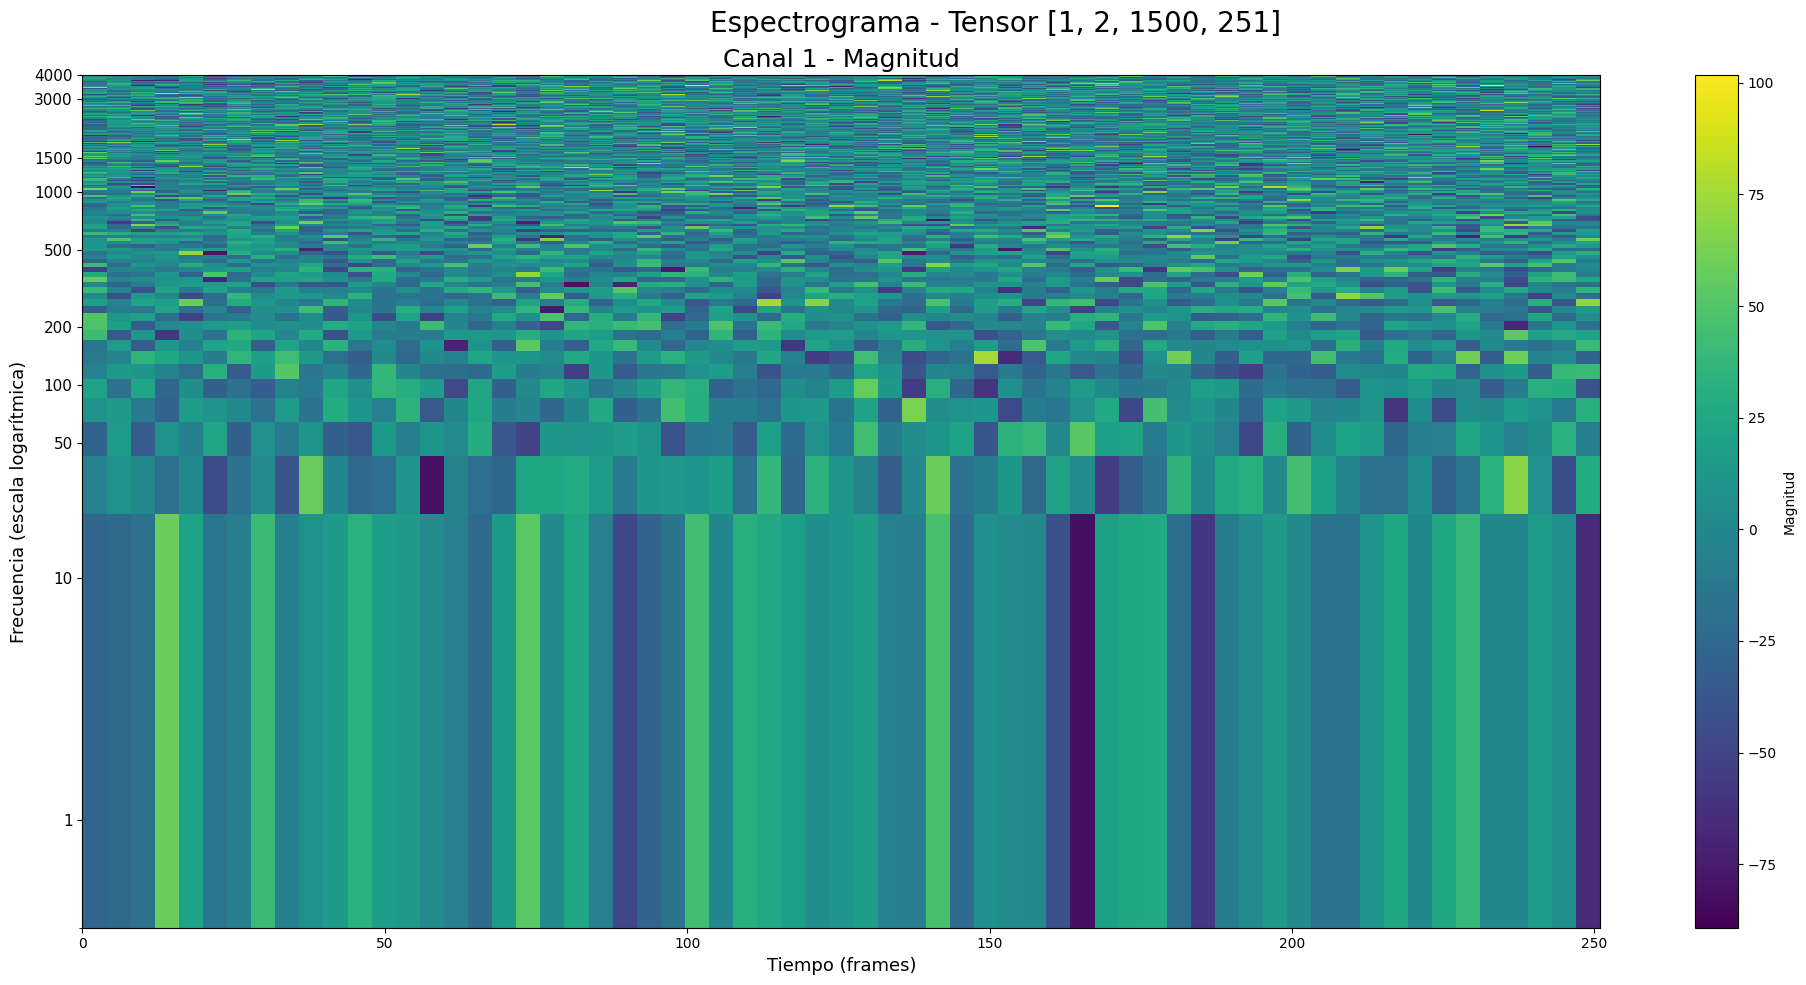

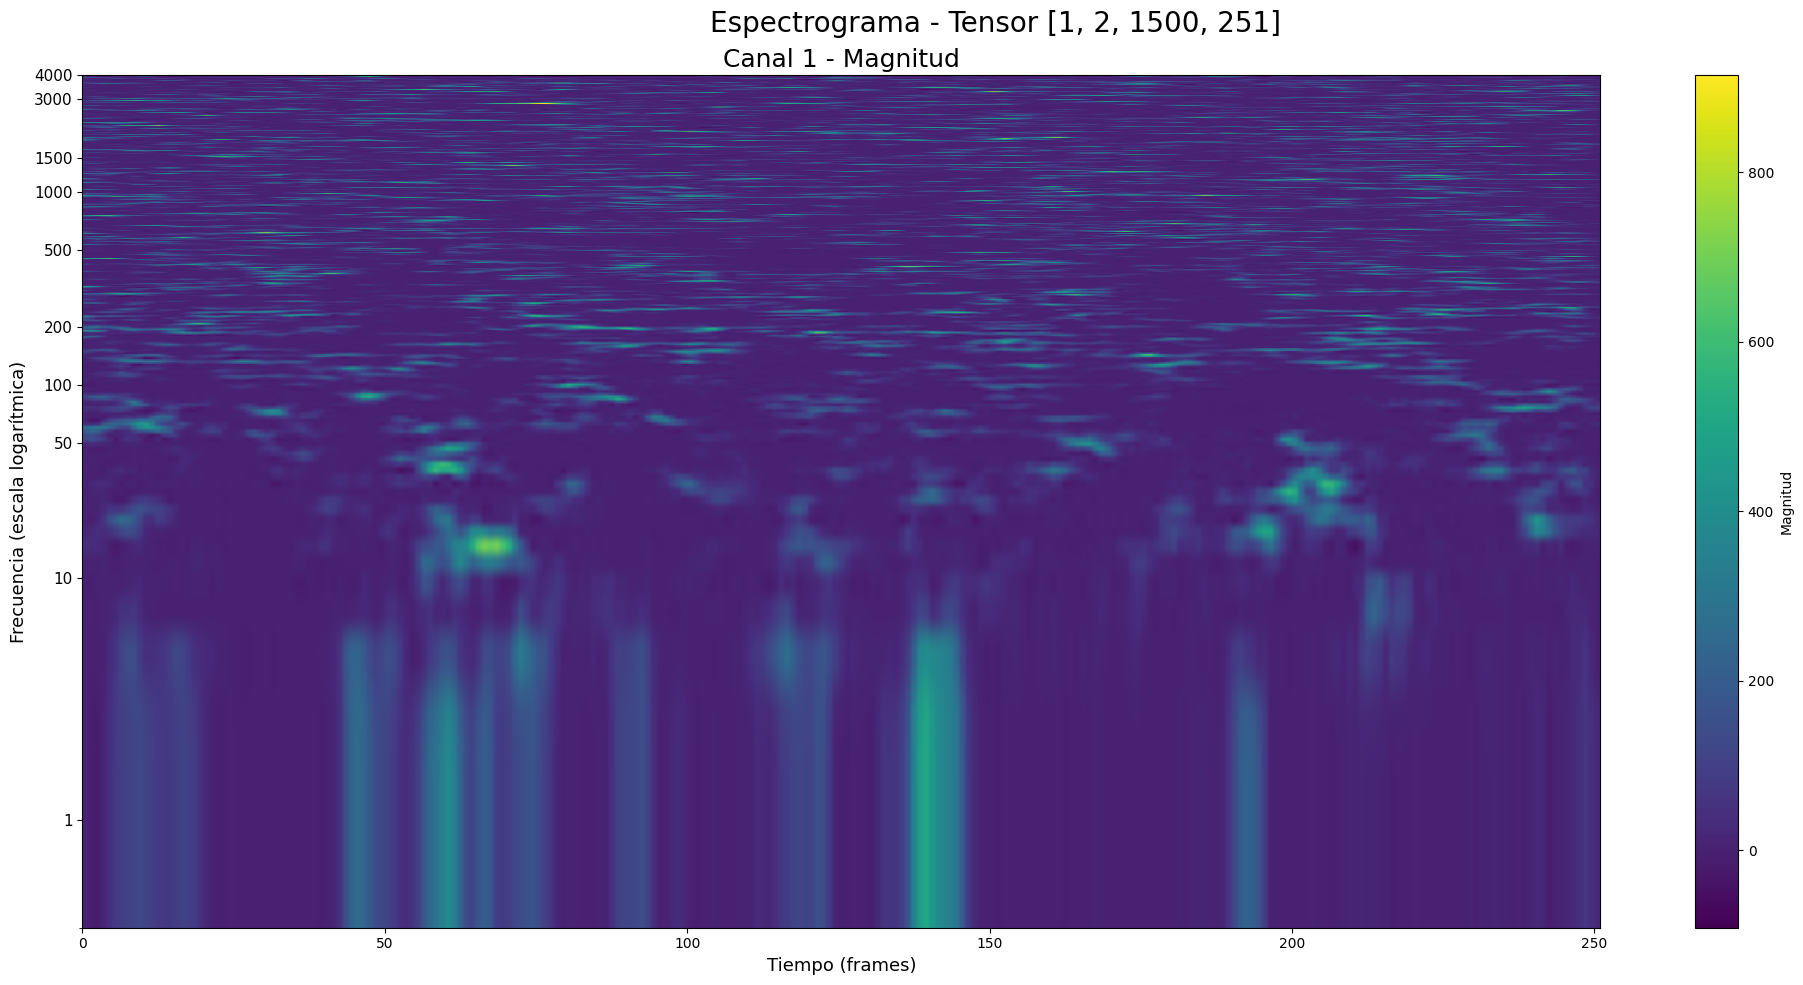

In [13]:
import soundfile as sf
import numpy as np

LATENT_VAE = True
if LATENT_VAE:
    latent_model, latent_scheduler = load_latent_model()

    z = sample_latent(latent_model, latent_scheduler, C=VAE_LATENT_DIM, num_samples=1).to(device)
    # TODO mirar si tengo que multiplicar por std mean para desnormalizarlos
    z = desnormalize_latent(z, source='vae_diffusion')

    del latent_model, latent_scheduler
    vae_model = load_vae(latent_dim=VAE_LATENT_DIM, channels=[2,16,32,64,128])
    with torch.no_grad():
        x = vae_model.decoder(z)
    print(z.shape)
    print(x.shape)
    display_tensor(z)
    display_tensor(x)
    # w = au.spectrogram_to_waveform(x)


In [14]:
import soundfile as sf
import numpy as np

LATENT_VAE = True
if LATENT_VAE:
    latent_model, latent_scheduler = load_latent_model()
    waves = sample_audio(
        load_vae(),
        latent_model, latent_scheduler,
        num_samples=1,
        n_fft=1500,
        win_length=1500
    )  
    print(waves[0].shape)
    del latent_model, latent_scheduler
    display_audio(waves)


{'timesteps': 1000, 'emb_dim': 128, 'hidden_dims': 64, 'latent_dim': 64, 'norm_groups': 8, 'deep': 3, 'increase_dims': True}
VAE Loaded
(62500,)


In [1]:
import json
from src.paths import PATHS

import torch
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

from src.dataset import NSynth
from src.latent_models import latent_VAE
from src.utils.models import compute_magnitude_and_phase, adjust_shape
from src.utils.dataset import INSTRUMENT_ID_2_STR
import torchaudio.transforms as T
import torchaudio

# # ---------------- STFT transform ----------------
# sample_rate = 16000
# n_fft = 1500
# hop_length = 250
# win_length = n_fft

# stft_transform = T.Spectrogram(
#     n_fft=n_fft, win_length=win_length, hop_length=hop_length,
#     power=None, onesided=True, center=False
# ).to(device)
# istft_transform = torchaudio.transforms.InverseSpectrogram(
#     n_fft=n_fft, win_length=win_length, hop_length=hop_length, onesided=False
# ).to(device)

# model = latent_VAE(input_size=input_size, latent_dim=VAE_LATENT_DIM, strides=VAE_STRIDES, channels=VAE_CHANNELS).to(device)
# model.load_state_dict(torch.load(model_path, map_location=device))
# model.eval()

# # ---------------- Dataset + loader ----------------



def extract_latents(loader, model, N=3000):
    """Pasa batches por el encoder y devuelve mu (flat), mu (pooled en tiempo),
    instrumento y pitch por muestra. Para en cuanto llega a N."""
    mus, mus_pooled, labels, pitches = [], [], [], []

    with torch.no_grad():
        for waveform, _, _, metadata in loader:
            waveform = waveform.to(device)
            S = stft_transform(waveform)
            mag, ph = compute_magnitude_and_phase(S)
            x = torch.cat([mag, ph], dim=1)              # [B,2,F,T]

            _, mu, _ = model.encoder(x)                  # [B, latent_dim, H, W]

            mus.append(mu.flatten(start_dim=1).cpu().numpy())

            mu_pooled = mu.mean(dim=3).flatten(start_dim=1)  # promedia en tiempo, conserva freq
            mus_pooled.append(mu_pooled.cpu().numpy())

            oh = metadata['one_hot_instrument']
            labels.extend(INSTRUMENT_ID_2_STR[int(v.argmax())] for v in oh)
            
            # pitch para contrastar la hipótesis del "arco" en el PCA
            if 'pitch' in metadata:
                pitches.extend(metadata['pitch'].cpu().numpy().tolist())

            if len(labels) >= N:
                break

    mus         = np.vstack(mus)[:N]
    mus_pooled  = np.vstack(mus_pooled)[:N]
    labels      = np.array(labels[:N])
    pitches     = np.array(pitches[:N]) if pitches else None
    return mus, mus_pooled, labels, pitches


def plot_pca(features, color_values, title, categorical=True, legend_title="Instrument"):
    """PCA a 2D + scatter. Si categorical=True, color_values son strings (instrumento);
    si no, color_values es un array numérico continuo (p.ej. pitch)."""
    pca = PCA(n_components=2)
    z2 = pca.fit_transform(features)
    var = pca.explained_variance_ratio_
    print(f"[{title}] varianza explicada PC1={var[0]:.3f} PC2={var[1]:.3f} "
          f"(total={var.sum():.3f})")

    plt.figure(figsize=(8, 6))

    if categorical:
        unique_vals = np.unique(color_values)
        val2code = {v: i for i, v in enumerate(unique_vals)}
        codes = np.array([val2code[v] for v in color_values])
        scatter = plt.scatter(z2[:, 0], z2[:, 1], c=codes, cmap='tab10', s=10, alpha=0.7)
        handles, _ = scatter.legend_elements(num=len(unique_vals))
        plt.legend(handles, unique_vals, title=legend_title, loc='best')
    else:
        scatter = plt.scatter(z2[:, 0], z2[:, 1], c=color_values, cmap='viridis', s=10, alpha=0.7)
        plt.colorbar(scatter, label=legend_title)

    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.title(title)
    plt.tight_layout()
    plt.show()
    return z2, var


# # ---------------- Run ----------------

# # Coloreado por instrumento (flat vs pooled)
# plot_pca(mus,        labels, "2D PCA of VAE Latent Means by Instrument")
# plot_pca(mus_pooled, labels, "2D PCA of VAE Latent Means by Instrument (Pooled)")

def sample_diffusion_latents(latent_model, latent_scheduler, N=3000, C=32, H=94, W=16,
                              batch_size=128, source='vae_diffusion'):
    """
    Genera N latentes aleatorios con el proceso reverso completo de difusión
    (igual que sample_latent, pero acumulando en batches hasta llegar a N).
    Devuelve un tensor [N, C, H, W] ya desnormalizado (misma escala que los mu del VAE).
    """
    latent_model.eval()

    betas, alphas, alpha_bars = latent_scheduler.beta, latent_scheduler.alpha, latent_scheduler.alpha_bar
    T_steps = alpha_bars.shape[0]

    with open(PATHS[source]['training_norm_params'], 'r') as f:
        stats = json.load(f)
    latent_mean = torch.tensor(stats['mean'])
    latent_std  = torch.tensor(stats['std'])

    all_latents = []
    remaining = N
    with torch.no_grad():
        while remaining > 0:
            b = min(batch_size, remaining)
            x = torch.randn(b, C, H, W, device=device)

            for t in reversed(range(T_steps)):
                t_batch = torch.full((b,), t, device=device, dtype=torch.long)
                e_pred = latent_model(x, t_batch)

                beta_t, alpha_t, alpha_bar_t = betas[t], alphas[t], alpha_bars[t]
                coef1 = 1 / torch.sqrt(alpha_t)
                coef2 = beta_t / torch.sqrt(1 - alpha_bar_t)
                mu = coef1 * (x - coef2 * e_pred)

                if t > 0:
                    noise = torch.randn_like(x)
                    sigma_t = torch.sqrt(beta_t)
                    x = mu + sigma_t * noise
                else:
                    x = mu

            all_latents.append((x.cpu() * latent_std) + latent_mean)
            remaining -= b

    return torch.cat(all_latents, dim=0)[:N]  # [N, C, H, W]


def extract_diffusion_features(latents):
    """Mismas dos vistas que extract_latents(): flat y pooled en tiempo."""
    mus_flat   = latents.flatten(start_dim=1).numpy()
    mus_pooled = latents.mean(dim=3).flatten(start_dim=1).numpy()
    return mus_flat, mus_pooled


def plot_pca_comparison(features_vae, features_diff, title,
                         label_vae="VAE (real)", label_diff="Diffusion (generado)"):
    """
    Ajusta un único PCA sobre la unión de ambos conjuntos (para que compartan
    el mismo sistema de coordenadas) y los pinta superpuestos.
    """
    combined = np.vstack([features_vae, features_diff])
    pca = PCA(n_components=2)
    z2 = pca.fit_transform(combined)
    var = pca.explained_variance_ratio_
    print(f"[{title}] varianza explicada PC1={var[0]:.3f} PC2={var[1]:.3f} (total={var.sum():.3f})")

    n_vae = features_vae.shape[0]
    z2_vae, z2_diff = z2[:n_vae], z2[n_vae:]

    plt.figure(figsize=(8, 6))
    plt.scatter(z2_vae[:, 0],  z2_vae[:, 1],  s=10, alpha=0.5, c='tab:blue',   label=label_vae)
    plt.scatter(z2_diff[:, 0], z2_diff[:, 1], s=10, alpha=0.5, c='tab:orange', label=label_diff)
    plt.xlabel("PCA Component 1"); plt.ylabel("PCA Component 2")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()
    return z2, var

dataset = NSynth(partition='testing')
loader  = DataLoader(dataset, batch_size=128, shuffle=True)


# ---------------- Run ----------------
latent_model, latent_scheduler = load_latent_model()  # 'vae_diffusion' por defecto
model = load_vae()  # <- carga el VAE para extraer el tamaño del latente
H_lat, W_lat = model.encoder.get_sizes()[-1]           # <- deriva el tamaño real, no lo hardcodees

diff_latents = sample_diffusion_latents(latent_model, latent_scheduler, N=10,
                                         C=VAE_LATENT_DIM, H=H_lat, W=W_lat)
del latent_model, latent_scheduler

mus_diff, mus_diff_pooled = extract_diffusion_features(diff_latents)

# Plot aparte, solo del espacio generado por difusión
z2 = PCA(n_components=2).fit_transform(mus_diff)
plt.figure(figsize=(8, 6))
plt.scatter(z2[:, 0], z2[:, 1], s=10, alpha=0.6, c='tab:orange')
plt.title("2D PCA of Diffusion-generated Latents")
plt.xlabel("PCA Component 1"); plt.ylabel("PCA Component 2")
plt.tight_layout(); plt.show()

# Comparación superpuesta VAE vs Difusión (flat y pooled)
mus, mus_pooled, labels, pitches = extract_latents(loader, model, N=3000)

plot_pca_comparison(mus,        mus_diff,        "VAE vs Diffusion latents (flat)")
plot_pca_comparison(mus_pooled, mus_diff_pooled, "VAE vs Diffusion latents (pooled)")

ModuleNotFoundError: No module named 'src'

# USING THE DECODER TO GENERATE AUDIO FROM LATENT VECTORS

In [ ]:
import librosa
import numpy as np
import soundfile as sf
from IPython.display import Audio, display

def spectrogram_to_waveform(tensor, hop_length=250, sample_rate=22050, 
                             n_iter=64, output_path="output.wav"):
    
    ch0 = tensor[0, 0].detach().cpu().numpy()  # [4000, 201]
    ch1 = tensor[0, 1].detach().cpu().numpy()

    F     = ch0.shape[0]       # 4000
    n_fft = (F - 1) * 2        # 7998

    print(f"Canal 1 en [-π,π]: {(-np.pi <= ch1).all() and (ch1 <= np.pi).all()}")

    # ── Intentar Real + Imaginario ───────────────────────────────────────────
    # Si canal 1 tiene negativos, es parte imaginaria del STFT
    if ch1.min() < 0:
        print("→ Interpretando como Real + Imaginario")
        complex_stft = ch0 + 1j * ch1
        audio_raw = librosa.istft(complex_stft, hop_length=hop_length,
                                   win_length=n_fft, n_fft=n_fft, center=False)
    else:
        # ── Ambos positivos → Griffin-Lim sobre canal 0 ──────────────────────
        print("→ Interpretando como magnitud, usando Griffin-Lim")
        audio_raw = librosa.griffinlim(
            ch0, n_iter=n_iter, hop_length=hop_length,
            win_length=n_fft, n_fft=n_fft, center=True,  # center=True evita spikes
        )
        # Recortar padding de center=True
        trim = n_fft // 2
        audio_raw = audio_raw[trim:-trim] if len(audio_raw) > 2*trim else audio_raw

    # ── Normalizar por percentil 99 (ignora spikes extremos) ─────────────────
    p99 = np.percentile(np.abs(audio_raw), 99)
    audio = np.clip(audio_raw / (p99 + 1e-8), -1.0, 1.0).astype(np.float32)

    sf.write(output_path, audio, sample_rate)
    print(f"✅ '{output_path}'  |  {len(audio)/sample_rate:.2f}s @ {sample_rate}Hz")
    print(f"   RMS={np.sqrt(np.mean(audio**2)):.4f}  max={np.abs(audio).max():.4f}")
    return audio, sample_rate




In [ ]:
from src.models import AutoEncoder

def load_encoder(input_height = 4000, input_width  = 201, latent_dim   = 200, channels = [2, 16, 32, 64], model_path=r"C:\Users\Articuno\Desktop\TFG-info\data\models\autoencoder_fase.pth"):
    model = AutoEncoder((input_height, input_width), latent_dim, channels).to(device)
    model.load_state_dict(torch.load(model_path))
    model.eval()
    print("Encoder Loaded")
    return model


In [ ]:
import soundfile as sf
import numpy as np

def plot(data, title, sr, x_axis, y_axis, x_label, y_label, colorbar_label):
    plt.figure(figsize=(10, 4))  # Create a new figure for the STFT spectrogram
    librosa.display.specshow(data, sr=sr, x_axis=x_axis, y_axis=y_axis) #fmax=8000
    plt.colorbar(label=colorbar_label) # format='%+2.0f'
    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.show()
    
n_fft = 4000
hop_length = 250

LATENT_DECODER = True
if LATENT_DECODER:
    latent_model, latent_scheduler = load_latent_model('encoder_latent')
    z = sample_latent(latent_model, latent_scheduler, latent_dim=200, num_samples=1, source='encoder_latent').to(device)
    del latent_model, latent_scheduler
    vae_model = load_encoder()
    with torch.no_grad():
        x = vae_model.decoder(z)
    print(z.shape)
    print(x.shape)
    display_tensor(x)
    
    mag   = x[0, 0].detach().cpu().numpy()  # canal 0
    phase = x[0, 1].detach().cpu().numpy()  # canal 1

    # Al reproducir:
    w, sr = spectrogram_to_waveform(x, hop_length=250, sample_rate=16000)
    w = w / (np.abs(w).max() + 1e-8)
    display(Audio(w, rate=sr))   
    print(np.max(w))
    librosa.display.waveshow(w, sr=sr)
    
    ft = np.abs(librosa.stft(w, n_fft=4000, hop_length=250))
    # 3. Mel Spectrogram (linear scale)
    mel_sp = librosa.feature.melspectrogram(y=w, sr=sr, n_fft=n_fft, hop_length=hop_length)
    plot(mel_sp, 'Linear Mel Spectrogram', sr, 'time', 'mel', 'Time (s)', 'Mel frequency bins', 'Amplitude squared')

    # 4. Mel Spectrogram (mel scale)
    mel_sp_dB = librosa.power_to_db(mel_sp, ref=np.max)



KeyError: 'encoder_latent'

In [ ]:
import soundfile as sf
import numpy as np

LATENT_DECODER = True
if LATENT_DECODER:
    latent_model, latent_scheduler = load_latent_model('encoder_latent')
    waves = sample_audio(load_encoder(), latent_model, latent_scheduler, win_length= 4000, n_fft=4000, hop_length=300, num_samples=5)
    print(waves[0].shape)
    del latent_model, latent_scheduler
    display_audio(waves)

Encoder Loaded
(60000,)


## Compare difusion latent distribution with test latent distribution:

In [ ]:
import torch
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

from src.dataset import NSynth
from src.latent_models import latent_VAE
from src.utils.models import compute_magnitude_and_phase, adjust_shape
from src.utils.dataset import INSTRUMENT_ID_2_STR
import torchaudio.transforms as T
import torchaudio

input_height = 1500
input_width = 251
input_size = (input_height, input_width)

# ---------------- STFT transform ----------------
sample_rate = 16000
n_fft = 1500
hop_length = 250
win_length = n_fft

stft_transform = T.Spectrogram(
    n_fft=n_fft, win_length=win_length, hop_length=hop_length,
    power=None, onesided=True, center=False
).to(device)
istft_transform = torchaudio.transforms.InverseSpectrogram(
    n_fft=n_fft, win_length=win_length, hop_length=hop_length, onesided=False
).to(device)

model = latent_VAE(input_size=input_size, latent_dim=VAE_LATENT_DIM, strides=VAE_STRIDES, channels=VAE_CHANNELS).to(device)
model.load_state_dict(torch.load(PATHS['VAE_2D']['model'], map_location=device))
model.eval()

# ---------------- Dataset + loader ----------------
dataset = NSynth(partition='testing')
loader  = DataLoader(dataset, batch_size=128, shuffle=True)


def extract_latents(loader, model, N=3000):
    """Pasa batches por el encoder y devuelve mu (flat), mu (pooled en tiempo),
    instrumento y pitch por muestra. Para en cuanto llega a N."""
    mus, mus_pooled, labels, pitches = [], [], [], []

    with torch.no_grad():
        for waveform, _, _, metadata in loader:
            waveform = waveform.to(device)
            S = stft_transform(waveform)
            mag, ph = compute_magnitude_and_phase(S)
            x = torch.cat([mag, ph], dim=1)              # [B,2,F,T]

            _, mu, _ = model.encoder(x)                  # [B, latent_dim, H, W]

            mus.append(mu.flatten(start_dim=1).cpu().numpy())

            mu_pooled = mu.mean(dim=3).flatten(start_dim=1)  # promedia en tiempo, conserva freq
            mus_pooled.append(mu_pooled.cpu().numpy())

            oh = metadata['one_hot_instrument']
            labels.extend(INSTRUMENT_ID_2_STR[int(v.argmax())] for v in oh)
            
            # pitch para contrastar la hipótesis del "arco" en el PCA
            if 'pitch' in metadata:
                pitches.extend(metadata['pitch'].cpu().numpy().tolist())

            if len(labels) >= N:
                break

    mus         = np.vstack(mus)[:N]
    mus_pooled  = np.vstack(mus_pooled)[:N]
    labels      = np.array(labels[:N])
    pitches     = np.array(pitches[:N]) if pitches else None
    return mus, mus_pooled, labels, pitches


def plot_pca(features, color_values, title, categorical=True, legend_title="Instrument"):
    """PCA a 2D + scatter. Si categorical=True, color_values son strings (instrumento);
    si no, color_values es un array numérico continuo (p.ej. pitch)."""
    pca = PCA(n_components=2)
    z2 = pca.fit_transform(features)
    var = pca.explained_variance_ratio_
    print(f"[{title}] varianza explicada PC1={var[0]:.3f} PC2={var[1]:.3f} "
          f"(total={var.sum():.3f})")

    plt.figure(figsize=(8, 6))

    if categorical:
        unique_vals = np.unique(color_values)
        val2code = {v: i for i, v in enumerate(unique_vals)}
        codes = np.array([val2code[v] for v in color_values])
        scatter = plt.scatter(z2[:, 0], z2[:, 1], c=codes, cmap='tab10', s=10, alpha=0.7)
        handles, _ = scatter.legend_elements(num=len(unique_vals))
        plt.legend(handles, unique_vals, title=legend_title, loc='best')
    else:
        scatter = plt.scatter(z2[:, 0], z2[:, 1], c=color_values, cmap='viridis', s=10, alpha=0.7)
        plt.colorbar(scatter, label=legend_title)

    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.title(title)
    plt.tight_layout()
    plt.show()
    return z2, var


# ---------------- Run ----------------
mus, mus_pooled, labels, pitches = extract_latents(loader, model, N=3000)

# Coloreado por instrumento (flat vs pooled)
plot_pca(mus,        labels, "2D PCA of VAE Latent Means by Instrument")
plot_pca(mus_pooled, labels, "2D PCA of VAE Latent Means by Instrument (Pooled)")